# Reinforcement Learning Blackjack Player
## Portfolio Exam 3: Reasoning and Decision Making under Uncertainty

This notebook implements a custom Blackjack RL agent. The execution is broken down into specific scenarios.


### Step 1: Library Imports


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import IPython.display as display


### Step 2: Blackjack Environment

Here we define `Card`, `Deck`, `Hand`, and `BlackjackEnv` with Thorp's strict Nevada rules.


In [12]:
import numpy as np

class Card:
    def __init__(self, rank):
        self.rank = rank
        if rank in ['J', 'Q', 'K']:
            self.value = 10
        elif rank == 'A':
            self.value = 11
        else:
            self.value = int(rank)

    def get_count_value(self):
        if self.value >= 10:
            return -1
        elif self.value <= 6:
            return 1
        return 0

    def __repr__(self):
        return self.rank

class Deck:
    def __init__(self, num_decks=1):
        self.num_decks = num_decks
        self.ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
        self.cards = []
        self.running_count = 0
        self.shuffle()

    def shuffle(self):
        self.cards = [Card(r) for r in self.ranks for _ in range(4 * self.num_decks)]
        np.random.shuffle(self.cards)
        self.running_count = 0
        self.burn() # Burn one card

    def burn(self):
        if self.cards:
            self.cards.pop()

    def draw(self):
        if not self.cards:
            self.shuffle()
        c = self.cards.pop()
        self.running_count += c.get_count_value()
        return c

    def get_true_count(self):
        decks_remaining = max(0.5, len(self.cards) / 52.0)
        return self.running_count / decks_remaining

    def needs_shuffle(self):
        # 75% penetration (only 25% cards left)
        return len(self.cards) < (52 * self.num_decks * 0.25)


class Hand:
    def __init__(self):
        self.cards = []
        self.wager = 1.0
        self.busted = False
        self.stood = False
        self.doubled = False
        self.surrendered = False
        self.is_split_ace = False
        self.is_natural = False

    def add_card(self, card):
        self.cards.append(card)

    def get_eval(self):
        hard_total = sum([c.value if c.rank != 'A' else 1 for c in self.cards])
        aces = sum([1 for c in self.cards if c.rank == 'A'])
        if aces > 0 and hard_total + 10 <= 21:
            return hard_total + 10, True
        return hard_total, False

    def check_natural(self):
        total, _ = self.get_eval()
        self.is_natural = (len(self.cards) == 2 and total == 21)
        return self.is_natural

class BlackjackEnv:
    def __init__(self, use_count=False, h17_rule=False, late_surrender=False, num_decks=1):
        self.use_count = use_count
        self.h17_rule = h17_rule
        self.late_surrender = late_surrender
        self.deck = Deck(num_decks)

        self.player_hands = []
        self.current_hand_idx = 0
        self.dealer_hand = Hand()
        self.dealer_upcard = None
        self.dealer_hole_card = None
        self.base_wager = 1.0

    def _get_tc_bin(self, tc):
        if tc <= -1.5: return 0
        elif tc <= -0.5: return 1
        elif tc <= 0.5: return 2
        elif tc <= 1.5: return 3
        else: return 4

    def reset(self, wager=1.0):
        if self.deck.needs_shuffle():
            self.deck.shuffle()

        self.base_wager = wager

        self.player_hands = [Hand()]
        self.player_hands[0].wager = wager
        self.current_hand_idx = 0
        self.dealer_hand = Hand()

        # Deal Sequence: Player, Dealer Up, Player, Dealer Hole
        self.player_hands[0].add_card(self.deck.draw())
        self.dealer_upcard = self.deck.draw()
        self.dealer_hand.add_card(self.dealer_upcard)

        self.player_hands[0].add_card(self.deck.draw())
        self.dealer_hole_card = self.deck.draw()
        self.dealer_hand.add_card(self.dealer_hole_card)

        # Check naturals instantly
        p_nat = self.player_hands[0].check_natural()
        d_nat = self.dealer_hand.check_natural()

        if p_nat or d_nat:
            # Game over immediately
            reward = self._settle_natural(p_nat, d_nat)
            return self._get_obs(), reward, True, {}

        return self._get_obs(), 0.0, False, {}

    def _settle_natural(self, p_nat, d_nat):
        if p_nat and not d_nat:
            return 1.5 * self.base_wager
        elif d_nat and not p_nat:
            return -1.0 * self.base_wager
        else:
            return 0.0 # Push

    def _get_obs(self):
        idx = min(self.current_hand_idx, len(self.player_hands) - 1)
        hand = self.player_hands[idx]
        total, usable_ace = hand.get_eval()

        # can split?
        can_split = False
        if len(hand.cards) == 2 and hand.cards[0].value == hand.cards[1].value:
            can_split = True

        d_up = self.dealer_upcard.value if self.dealer_upcard else 0

        if self.use_count:
            tc_bin = self._get_tc_bin(self.deck.get_true_count())
            return (total, d_up, usable_ace, can_split, tc_bin)
        else:
            return (total, d_up, usable_ace, can_split)

    def get_valid_actions(self):
        hand = self.player_hands[self.current_hand_idx]
        actions = [0, 1] # Stand, Hit

        # Double Down
        if len(hand.cards) == 2 and not hand.is_split_ace:
            actions.append(2)

        # Split
        if len(hand.cards) == 2 and hand.cards[0].value == hand.cards[1].value and not hand.is_split_ace:
            actions.append(3)

        # Surrender
        if self.late_surrender and len(hand.cards) == 2 and len(self.player_hands) == 1:
            actions.append(4)

        return actions

    def step(self, action):
        """
        Actions:
        0: Stand
        1: Hit
        2: Double Down
        3: Split
        4: Surrender
        """
        valid_actions = self.get_valid_actions()
        if action not in valid_actions:
            # If invalid, fallback to Hit if possible, else Stand
            if 1 in valid_actions:
                action = 1
            else:
                action = 0

        hand = self.player_hands[self.current_hand_idx]
        done = False
        reward = 0.0

        if action == 4 and self.late_surrender:
            # Late surrender only allowed on first two cards, before any action
            if len(hand.cards) == 2 and len(self.player_hands) == 1:
                hand.surrendered = True
                reward = -0.5 * hand.wager
                return self._get_obs(), reward, True, {}

        if action == 3 and len(hand.cards) == 2 and hand.cards[0].value == hand.cards[1].value:
            # Valid Split
            new_hand = Hand()
            new_hand.wager = hand.wager

            c1, c2 = hand.cards[0], hand.cards[1]
            hand.cards = [c1]
            new_hand.cards = [c2]

            # Draw one card for each
            hand.add_card(self.deck.draw())
            new_hand.add_card(self.deck.draw())

            if c1.rank == 'A':
                hand.is_split_ace = True
                new_hand.is_split_ace = True
                # Ace split constraint: only one card, force stand
                hand.stood = True
                new_hand.stood = True

            self.player_hands.insert(self.current_hand_idx + 1, new_hand)
            # We don't increment index yet, we still play the first hand (unless ace split forced stand)
            if hand.stood:
                 self.current_hand_idx += 1
                 if self.current_hand_idx < len(self.player_hands):
                     if self.player_hands[self.current_hand_idx].stood:
                         self.current_hand_idx += 1

        elif action == 2 and len(hand.cards) == 2:
            # Valid Double Down
            hand.doubled = True
            hand.wager *= 2
            hand.add_card(self.deck.draw())
            total, _ = hand.get_eval()
            if total > 21:
                hand.busted = True
            hand.stood = True
            self.current_hand_idx += 1

        elif action == 1:
            # Hit
            hand.add_card(self.deck.draw())
            total, _ = hand.get_eval()
            if total > 21:
                hand.busted = True
                self.current_hand_idx += 1

        elif action == 0:
            # Stand
            hand.stood = True
            self.current_hand_idx += 1

        # Check if all hands are resolved
        if self.current_hand_idx >= len(self.player_hands):
            done = True
            reward = self._evaluate_game()

        if not done:
            return self._get_obs(), 0.0, False, {}
        else:
            return self._get_obs(), reward, True, {}

    def _evaluate_game(self):
        # Determine if we even need to play the dealer hand
        # If all hands are busted or surrendered, dealer doesn't need to draw
        all_busted_or_surrendered = all(h.busted or h.surrendered for h in self.player_hands)

        if not all_busted_or_surrendered:
            # Play dealer hand
            while True:
                d_total, d_soft = self.dealer_hand.get_eval()
                if d_total > 21:
                    break
                if d_total > 17:
                    break
                if d_total == 17 and not d_soft:
                    break
                if d_total == 17 and d_soft and not self.h17_rule:
                    break
                # Must hit
                self.dealer_hand.add_card(self.deck.draw())

        d_total, _ = self.dealer_hand.get_eval()

        total_reward = 0.0
        for h in self.player_hands:
            if h.surrendered:
                # Surrender reward already handled? Actually I handled it as immediate return.
                # Wait, if multiple hands? Surrender is only on original hand.
                pass
            elif h.busted:
                total_reward -= h.wager
            elif d_total > 21:
                total_reward += h.wager
            else:
                p_total, _ = h.get_eval()
                if p_total > d_total:
                    total_reward += h.wager
                elif p_total < d_total:
                    total_reward -= h.wager
                else:
                    # Push, reward = 0
                    pass

        return total_reward


### Step 3: RL Agents

Defining the Q-Learning and SARSA agents.


In [13]:
class BaseAgent:
    def __init__(self, action_space_size=5, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.999995, epsilon_min=0.01):
        self.action_space_size = action_space_size
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Default dict initializes unseen states with zeros for all actions
        self.q_table = defaultdict(lambda: np.zeros(self.action_space_size))

    def get_action(self, state, valid_actions):
        if np.random.rand() < self.epsilon:
            return np.random.choice(valid_actions)

        return self.get_greedy_action(state, valid_actions)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_greedy_action(self, state, valid_actions):
        q_values = self.q_table[state]
        valid_q = {a: q_values[a] for a in valid_actions}
        max_val = max(valid_q.values())
        best_actions = [a for a, v in valid_q.items() if v == max_val]
        # In case of ties, choose randomly among the best to prevent bias,
        # though during strict evaluation we might just take the first.
        return np.random.choice(best_actions)

class QLearningAgent(BaseAgent):
    def update(self, state, action, reward, next_state, done, next_valid_actions):
        if done:
            target = reward
        else:
            # max over next_valid_actions
            next_q_values = self.q_table[next_state]
            max_next_q = max([next_q_values[a] for a in next_valid_actions])
            target = reward + self.gamma * max_next_q

        current_q = self.q_table[state][action]
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)

class SARSAAgent(BaseAgent):
    def update(self, state, action, reward, next_state, next_action, done):
        if done:
            target = reward
        else:
            target = reward + self.gamma * self.q_table[next_state][next_action]

        current_q = self.q_table[state][action]
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)


### Step 4: Training & Plotting Functions

Defines the loop to train the agents, tracking the rolling win percentage and the epsilon decay value to plot later.


In [14]:
TRAIN_EPISODES = 500000
EVAL_EPISODES = 50000
WINDOW_SIZE = 10000

def train_q_learning(env, agent, episodes, dynamic_bet=False):
    win_history = []
    eps_history = []
    win_buffer = np.zeros(WINDOW_SIZE)
    win_sum = 0

    for e in range(episodes):
        wager = 1.0
        if dynamic_bet:
            tc = env.deck.get_true_count()
            if tc > 1.5: wager = 5.0
            elif tc > 0.5: wager = 2.0
            else: wager = 1.0

        state, _, done, _ = env.reset(wager=wager)

        while not done:
            valid_actions = env.get_valid_actions()
            action = agent.get_action(state, valid_actions)
            next_state, reward, done, _ = env.step(action)

            if done:
                agent.update(state, action, reward, next_state, done, [])
            else:
                next_valid_actions = env.get_valid_actions()
                agent.update(state, action, reward, next_state, done, next_valid_actions)
                state = next_state

        idx = e % WINDOW_SIZE
        win_sum -= win_buffer[idx]
        is_win = 1 if reward > 0 else 0
        win_buffer[idx] = is_win
        win_sum += is_win

        if (e + 1) % (episodes // 100) == 0:
            actual_window = min(e + 1, WINDOW_SIZE)
            win_history.append((win_sum / actual_window) * 100.0)
            eps_history.append(agent.epsilon)

        agent.decay_epsilon()

    return win_history, eps_history

def train_sarsa(env, agent, episodes, dynamic_bet=False):
    win_history = []
    eps_history = []
    win_buffer = np.zeros(WINDOW_SIZE)
    win_sum = 0

    for e in range(episodes):
        wager = 1.0
        if dynamic_bet:
            tc = env.deck.get_true_count()
            if tc > 1.5: wager = 5.0
            elif tc > 0.5: wager = 2.0
            else: wager = 1.0

        state, r, done, _ = env.reset(wager=wager)
        if done:
            reward = r
        else:
            valid_actions = env.get_valid_actions()
            action = agent.get_action(state, valid_actions)

            while not done:
                next_state, reward, done, _ = env.step(action)
                if done:
                    agent.update(state, action, reward, next_state, None, done)
                else:
                    next_valid_actions = env.get_valid_actions()
                    next_action = agent.get_action(next_state, next_valid_actions)
                    agent.update(state, action, reward, next_state, next_action, done)
                    state = next_state
                    action = next_action
                    valid_actions = next_valid_actions

        idx = e % WINDOW_SIZE
        win_sum -= win_buffer[idx]
        is_win = 1 if reward > 0 else 0
        win_buffer[idx] = is_win
        win_sum += is_win

        if (e + 1) % (episodes // 100) == 0:
            actual_window = min(e + 1, WINDOW_SIZE)
            win_history.append((win_sum / actual_window) * 100.0)
            eps_history.append(agent.epsilon)

        agent.decay_epsilon()

    return win_history, eps_history

def evaluate(env, agent, episodes, dynamic_bet=False):
    wins, losses, pushes, total_reward = 0, 0, 0, 0.0
    for _ in range(episodes):
        wager = 1.0
        if dynamic_bet:
            tc = env.deck.get_true_count()
            if tc > 1.5: wager = 5.0
            elif tc > 0.5: wager = 2.0
            else: wager = 1.0

        state, r, done, _ = env.reset(wager=wager)
        if done: reward = r
        else:
            while not done:
                valid_actions = env.get_valid_actions()
                action = agent.get_greedy_action(state, valid_actions)
                state, reward, done, _ = env.step(action)

        total_reward += reward
        if reward > 0: wins += 1
        elif reward < 0: losses += 1
        else: pushes += 1

    return wins/episodes, losses/episodes, pushes/episodes, total_reward/episodes

def plot_learning_curve(title, q_hist, s_hist, q_eps, train_eps):
    x_axis = np.linspace(0, train_eps, len(q_hist))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Agent Performance
    ax1.set_xlabel('Episodes')
    ax1.set_ylabel('Win Percentage (%)', color='black')
    ax1.plot(x_axis, q_hist, label=f'Q-Learning Win ({q_hist[-1]:.2f}%)', color='#1f77b4', linewidth=1.5)
    if s_hist:
        ax1.plot(x_axis, s_hist, label=f'SARSA Win ({s_hist[-1]:.2f}%)', color='#ff7f0e', linewidth=1.5)

    ax1.grid(True, linestyle='-', alpha=0.3, color='lightgrey')
    ax1.set_title(f'Agent Performance: {title}')
    ax1.legend(loc='upper left', framealpha=0.9, fontsize=9)

    # Plot 2: Epsilon Decay
    ax2.set_xlabel('Episodes')
    ax2.set_ylabel('Epsilon Value', color='black')
    ax2.plot(x_axis, q_eps, label='Epsilon Decay', color='gray', linestyle='--', linewidth=2)
    ax2.grid(True, linestyle='-', alpha=0.3, color='lightgrey')
    ax2.set_title('Exploration Rate (Epsilon Decay)')
    ax2.legend(loc='upper right', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.show()


## Scenario 1: Basic Strategy
Training agents purely on the player hand vs dealer upcard.


Training Q-Learning (Basic)...
Q-Learning RTP: -4.56% | Win: 42.36%
Training SARSA (Basic)...
SARSA RTP: -5.37% | Win: 41.78%


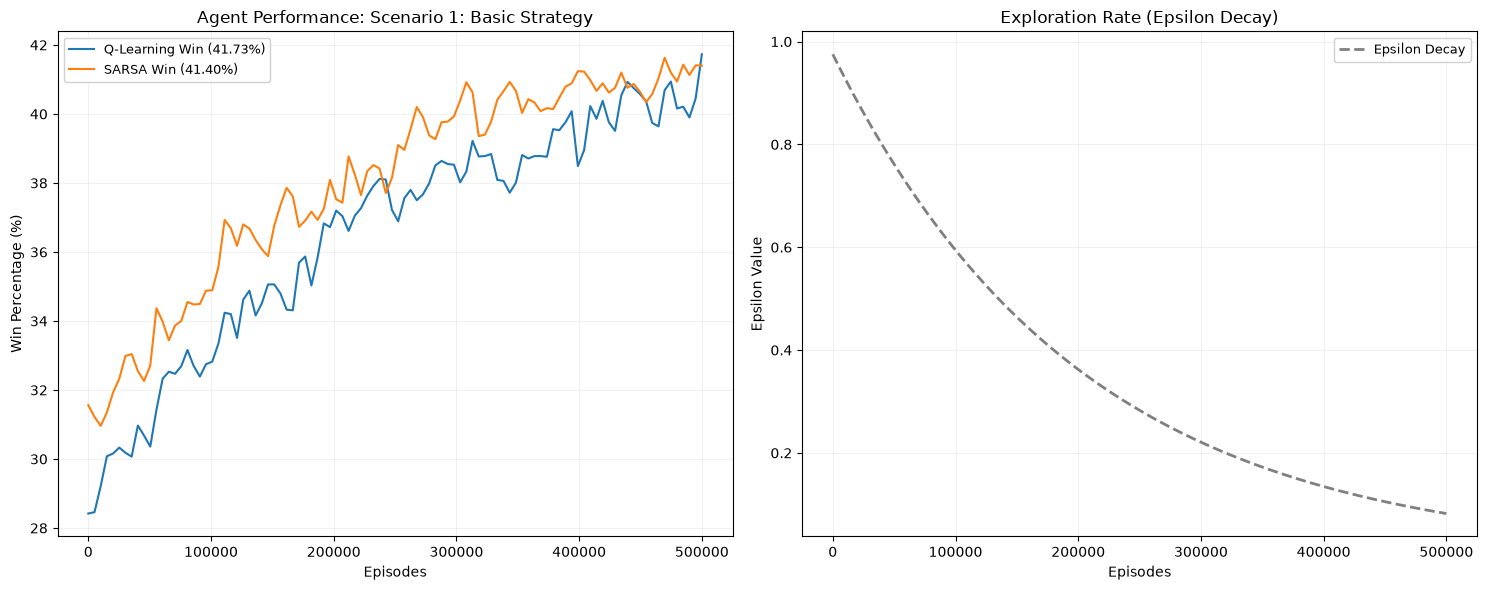

In [15]:
env1 = BlackjackEnv(use_count=False)

print("Training Q-Learning (Basic)...")
q_agent = QLearningAgent(epsilon_decay=0.999995)
q_hist, q_eps = train_q_learning(env1, q_agent, TRAIN_EPISODES, dynamic_bet=False)
q_w, q_l, q_p, q_rtp = evaluate(env1, q_agent, EVAL_EPISODES, dynamic_bet=False)
print(f"Q-Learning RTP: {q_rtp*100:.2f}% | Win: {q_w*100:.2f}%")

print("Training SARSA (Basic)...")
s_agent = SARSAAgent(epsilon_decay=0.999995)
s_hist, s_eps = train_sarsa(env1, s_agent, TRAIN_EPISODES, dynamic_bet=False)
s_w, s_l, s_p, s_rtp = evaluate(env1, s_agent, EVAL_EPISODES, dynamic_bet=False)
print(f"SARSA RTP: {s_rtp*100:.2f}% | Win: {s_w*100:.2f}%")

plot_learning_curve("Scenario 1: Basic Strategy", q_hist, s_hist, q_eps, TRAIN_EPISODES)


## Scenario 2: Complete Point-Count
Enabling Hi-Lo true count binning in the state space and dynamic bet sizing.


Training Q-Learning (Point-Count)...
Q-Learning RTP: -8.72% | Win: 41.92%
Training SARSA (Point-Count)...
SARSA RTP: -10.12% | Win: 42.11%


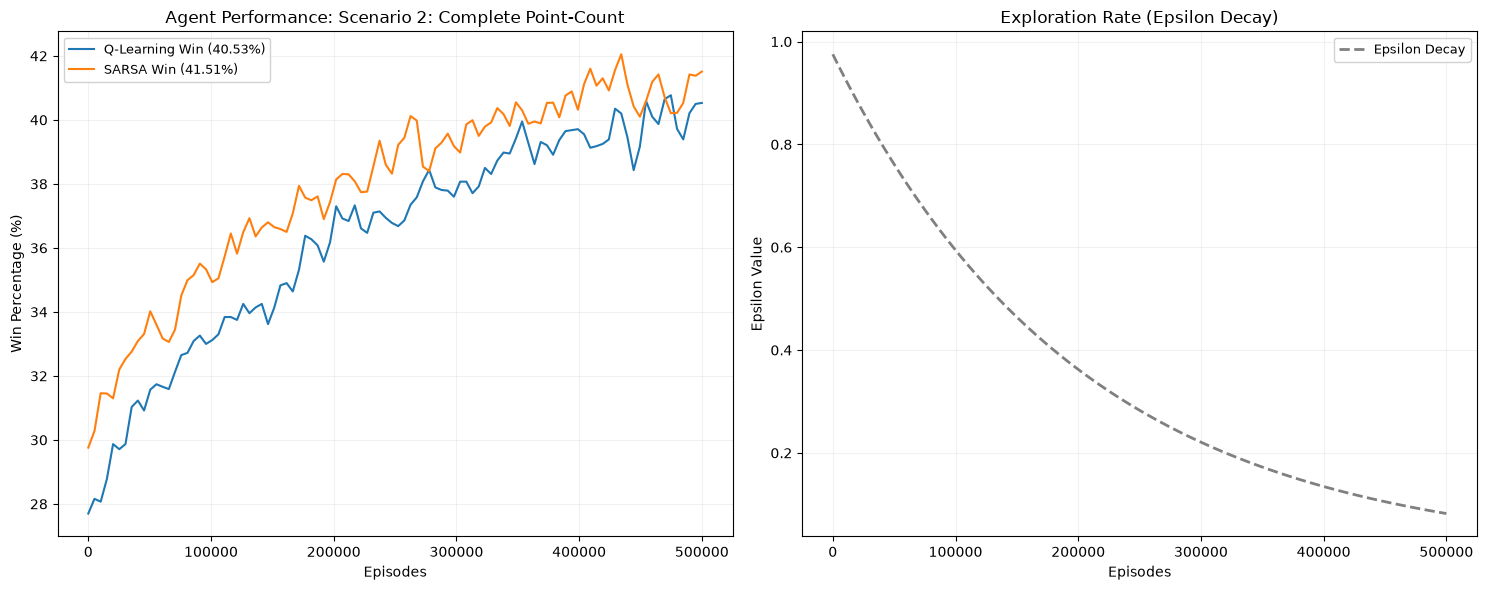

In [17]:
env2 = BlackjackEnv(use_count=True)

print("Training Q-Learning (Point-Count)...")
q_agent2 = QLearningAgent(epsilon_decay=0.999995)
q_hist2, q_eps2 = train_q_learning(env2, q_agent2, TRAIN_EPISODES, dynamic_bet=True)
q_w2, q_l2, q_p2, q_rtp2 = evaluate(env2, q_agent2, EVAL_EPISODES, dynamic_bet=True)
print(f"Q-Learning RTP: {q_rtp2*100:.2f}% | Win: {q_w2*100:.2f}%")

print("Training SARSA (Point-Count)...")
s_agent2 = SARSAAgent(epsilon_decay=0.999995)
s_hist2, s_eps2 = train_sarsa(env2, s_agent2, TRAIN_EPISODES, dynamic_bet=True)
s_w2, s_l2, s_p2, s_rtp2 = evaluate(env2, s_agent2, EVAL_EPISODES, dynamic_bet=True)
print(f"SARSA RTP: {s_rtp2*100:.2f}% | Win: {s_w2*100:.2f}%")

plot_learning_curve("Scenario 2: Complete Point-Count", q_hist2, s_hist2, q_eps2, TRAIN_EPISODES)


## Scenario 3A: Rule Variation - Dealer H17
Dealer must hit on a soft 17. Evaluated against basic strategy.


Training Q-Learning (H17)...
Q-Learning RTP: -4.05%
Training SARSA (H17)...
SARSA RTP: -3.98%


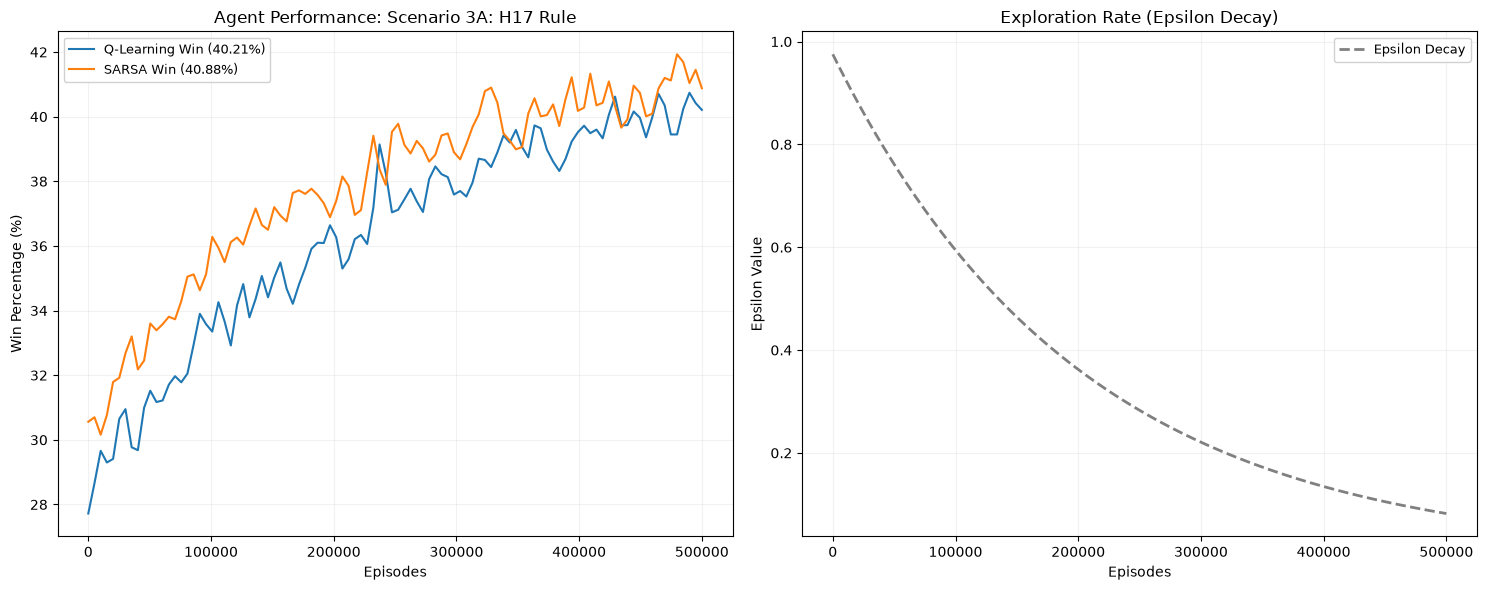

In [18]:
env3a = BlackjackEnv(use_count=False, h17_rule=True)

print("Training Q-Learning (H17)...")
q_agent3a = QLearningAgent(epsilon_decay=0.999995)
q_hist3a, q_eps3a = train_q_learning(env3a, q_agent3a, TRAIN_EPISODES, dynamic_bet=False)
q_w3a, q_l3a, q_p3a, q_rtp3a = evaluate(env3a, q_agent3a, EVAL_EPISODES, dynamic_bet=False)
print(f"Q-Learning RTP: {q_rtp3a*100:.2f}%")

print("Training SARSA (H17)...")
s_agent3a = SARSAAgent(epsilon_decay=0.999995)
s_hist3a, s_eps3a = train_sarsa(env3a, s_agent3a, TRAIN_EPISODES, dynamic_bet=False)
s_w3a, s_l3a, s_p3a, s_rtp3a = evaluate(env3a, s_agent3a, EVAL_EPISODES, dynamic_bet=False)
print(f"SARSA RTP: {s_rtp3a*100:.2f}%")

plot_learning_curve("Scenario 3A: H17 Rule", q_hist3a, s_hist3a, q_eps3a, TRAIN_EPISODES)


## Scenario 3B: Rule Variation - Late Surrender
Players can surrender their hand for 50% of their bet.


Training Q-Learning (Surrender)...
Q-Learning RTP: -5.40%
Training SARSA (Surrender)...
SARSA RTP: -5.94%


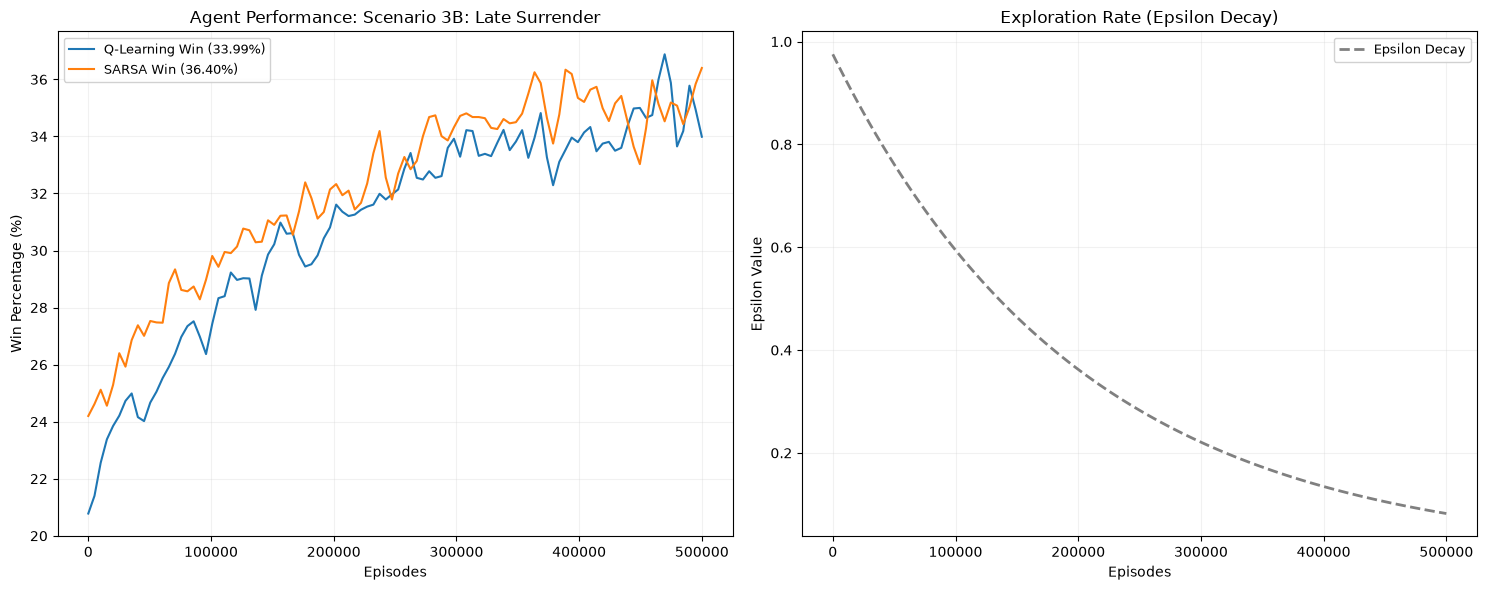

In [19]:
env3b = BlackjackEnv(use_count=False, late_surrender=True)

print("Training Q-Learning (Surrender)...")
q_agent3b = QLearningAgent(epsilon_decay=0.999995)
q_hist3b, q_eps3b = train_q_learning(env3b, q_agent3b, TRAIN_EPISODES, dynamic_bet=False)
q_w3b, q_l3b, q_p3b, q_rtp3b = evaluate(env3b, q_agent3b, EVAL_EPISODES, dynamic_bet=False)
print(f"Q-Learning RTP: {q_rtp3b*100:.2f}%")

print("Training SARSA (Surrender)...")
s_agent3b = SARSAAgent(epsilon_decay=0.999995)
s_hist3b, s_eps3b = train_sarsa(env3b, s_agent3b, TRAIN_EPISODES, dynamic_bet=False)
s_w3b, s_l3b, s_p3b, s_rtp3b = evaluate(env3b, s_agent3b, EVAL_EPISODES, dynamic_bet=False)
print(f"SARSA RTP: {s_rtp3b*100:.2f}%")

plot_learning_curve("Scenario 3B: Late Surrender", q_hist3b, s_hist3b, q_eps3b, TRAIN_EPISODES)


## Scenario 3C: Cross-Analysis (Rules + Card Counting)
Combining the Complete Point-Count System with both H17 and Late Surrender rules to analyze rule impacts on a card counter.


Training Q-Learning (Cross-Analysis)...
Q-Learning RTP: -16.14%
Training SARSA (Cross-Analysis)...
SARSA RTP: -9.68%


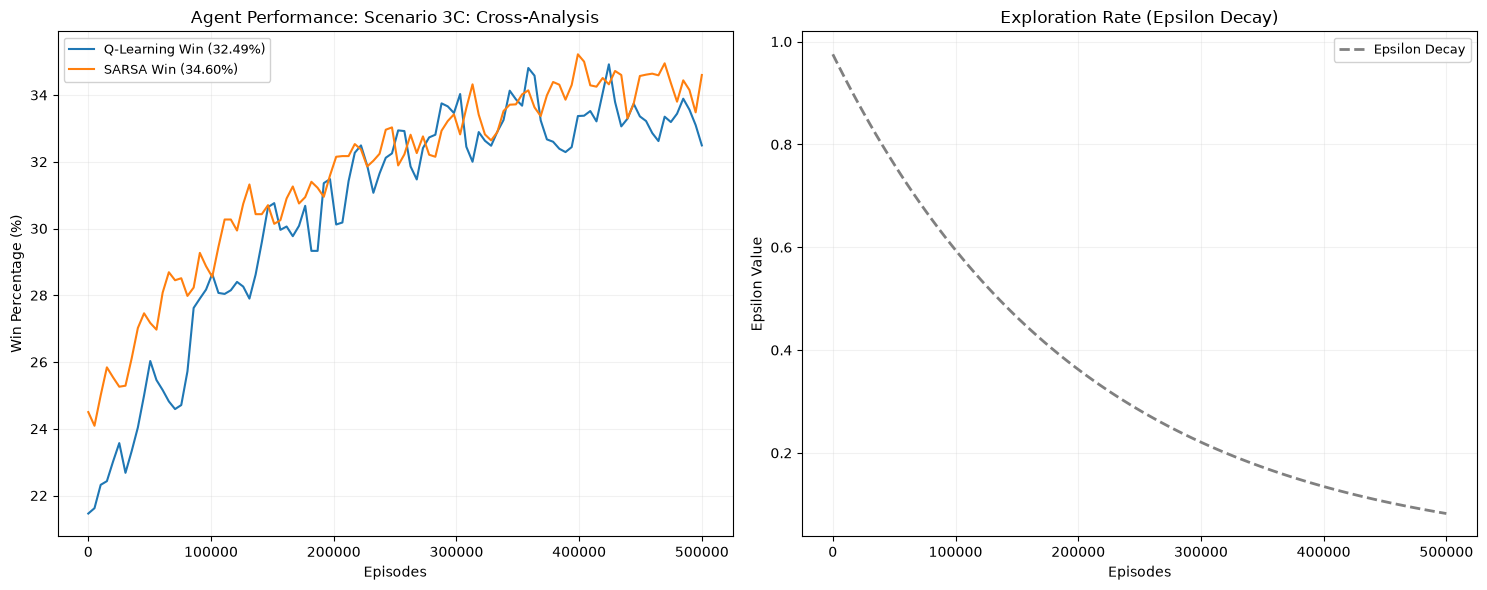

In [20]:
env3c = BlackjackEnv(use_count=True, h17_rule=True, late_surrender=True)

print("Training Q-Learning (Cross-Analysis)...")
q_agent3c = QLearningAgent(epsilon_decay=0.999995)
q_hist3c, q_eps3c = train_q_learning(env3c, q_agent3c, TRAIN_EPISODES, dynamic_bet=True)
q_w3c, q_l3c, q_p3c, q_rtp3c = evaluate(env3c, q_agent3c, EVAL_EPISODES, dynamic_bet=True)
print(f"Q-Learning RTP: {q_rtp3c*100:.2f}%")

print("Training SARSA (Cross-Analysis)...")
s_agent3c = SARSAAgent(epsilon_decay=0.999995)
s_hist3c, s_eps3c = train_sarsa(env3c, s_agent3c, TRAIN_EPISODES, dynamic_bet=True)
s_w3c, s_l3c, s_p3c, s_rtp3c = evaluate(env3c, s_agent3c, EVAL_EPISODES, dynamic_bet=True)
print(f"SARSA RTP: {s_rtp3c*100:.2f}%")

plot_learning_curve("Scenario 3C: Cross-Analysis", q_hist3c, s_hist3c, q_eps3c, TRAIN_EPISODES)



## Scenario 4: System Optimization (Super-Human High-Profit System)
Extended training cycle (1,000,000 episodes) with a hyper-aggressive 10x betting spread mapped to True Count.


Training Q-Learning (Optimized 1M Episodes)...
Q-Learning RTP: -8.15%
Training SARSA (Optimized 1M Episodes)...
SARSA RTP: -13.09%


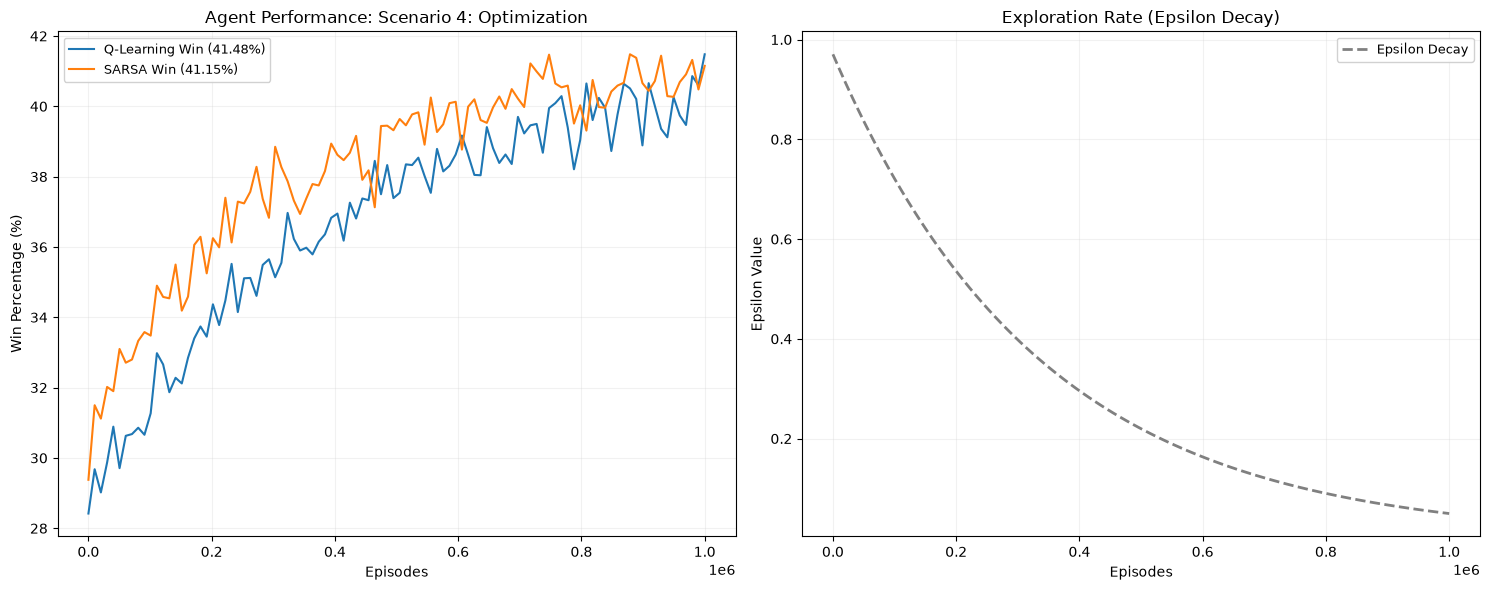

In [21]:
OPT_EPISODES = 1_000_000
EVAL_EPISODES = 50_000

env4 = BlackjackEnv(use_count=True)
# Hyper-aggressive dynamic betting wrapper
original_reset = env4.reset
def aggressive_reset(wager=1.0):
    tc = env4.deck.get_true_count()
    if tc > 2.0: wager = 10.0
    elif tc > 1.0: wager = 5.0
    elif tc > 0.0: wager = 2.0
    else: wager = 1.0
    return original_reset(wager=wager)
env4.reset = aggressive_reset

print("Training Q-Learning (Optimized 1M Episodes)...")
q_agent4 = QLearningAgent(epsilon_decay=0.999997) # Slower decay for longer training
q_hist4, q_eps4 = train_q_learning(env4, q_agent4, OPT_EPISODES, dynamic_bet=True)
q_w4, q_l4, q_p4, q_rtp4 = evaluate(env4, q_agent4, EVAL_EPISODES, dynamic_bet=True)
print(f"Q-Learning RTP: {q_rtp4*100:.2f}%")

print("Training SARSA (Optimized 1M Episodes)...")
s_agent4 = SARSAAgent(epsilon_decay=0.999997)
s_hist4, s_eps4 = train_sarsa(env4, s_agent4, OPT_EPISODES, dynamic_bet=True)
s_w4, s_l4, s_p4, s_rtp4 = evaluate(env4, s_agent4, EVAL_EPISODES, dynamic_bet=True)
print(f"SARSA RTP: {s_rtp4*100:.2f}%")

plot_learning_curve("Scenario 4: Optimization", q_hist4, s_hist4, q_eps4, OPT_EPISODES)



## Logfile Exporter
Automated export of training histories, win rates, RTP, and Q-table sizes to CSV and JSON.


In [22]:
import csv
import json

# Compile results
results = [
    {"scenario": "Scenario 1: Basic Strategy", "q_rtp": q_rtp, "q_win": q_w, "q_loss": q_l, "q_push": q_p, "sarsa_rtp": s_rtp, "sarsa_win": s_w, "sarsa_loss": s_l, "sarsa_push": s_p, "q_states": len(q_agent.q_table), "sarsa_states": len(s_agent.q_table)},
    {"scenario": "Scenario 2: Complete Point-Count", "q_rtp": q_rtp2, "q_win": q_w2, "q_loss": q_l2, "q_push": q_p2, "sarsa_rtp": s_rtp2, "sarsa_win": s_w2, "sarsa_loss": s_l2, "sarsa_push": s_p2, "q_states": len(q_agent2.q_table), "sarsa_states": len(s_agent2.q_table)},
    {"scenario": "Scenario 3A: H17 Rule", "q_rtp": q_rtp3a, "q_win": q_w3a, "q_loss": q_l3a, "q_push": q_p3a, "sarsa_rtp": s_rtp3a, "sarsa_win": s_w3a, "sarsa_loss": s_l3a, "sarsa_push": s_p3a, "q_states": len(q_agent3a.q_table), "sarsa_states": len(s_agent3a.q_table)},
    {"scenario": "Scenario 3B: Late Surrender", "q_rtp": q_rtp3b, "q_win": q_w3b, "q_loss": q_l3b, "q_push": q_p3b, "sarsa_rtp": s_rtp3b, "sarsa_win": s_w3b, "sarsa_loss": s_l3b, "sarsa_push": s_p3b, "q_states": len(q_agent3b.q_table), "sarsa_states": len(s_agent3b.q_table)},
    {"scenario": "Scenario 3C: Cross-Analysis", "q_rtp": q_rtp3c, "q_win": q_w3c, "q_loss": q_l3c, "q_push": q_p3c, "sarsa_rtp": s_rtp3c, "sarsa_win": s_w3c, "sarsa_loss": s_l3c, "sarsa_push": s_p3c, "q_states": len(q_agent3c.q_table), "sarsa_states": len(s_agent3c.q_table)},
    {"scenario": "Scenario 4: Optimization", "q_rtp": q_rtp4, "q_win": q_w4, "q_loss": q_l4, "q_push": q_p4, "sarsa_rtp": s_rtp4, "sarsa_win": s_w4, "sarsa_loss": s_l4, "sarsa_push": s_p4, "q_states": len(q_agent4.q_table), "sarsa_states": len(s_agent4.q_table)}
]

# Export CSV
with open("results_log.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)
print("Saved results_log.csv")

# Export JSON learning curves (just saving final values to save space)
curves = {
    "scenario_1": {"q_hist": q_hist[-100:], "s_hist": s_hist[-100:]},
    "scenario_2": {"q_hist": q_hist2[-100:], "s_hist": s_hist2[-100:]},
    "scenario_4": {"q_hist": q_hist4[-100:], "s_hist": s_hist4[-100:]}
}
with open("learning_curves.json", "w") as f:
    json.dump(curves, f)
print("Saved learning_curves.json")



Saved results_log.csv
Saved learning_curves.json
